# MobileNetV2

In [ ]:
# ============================================================
#  1: المكتبات والإعدادات الأساسية
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, cohen_kappa_score,
                             matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# تثبيت ONNX إذا لم يكن مثبتاً
try:
    import tf2onnx
except ImportError:
    print("Installing tf2onnx and onnx...")
    os.system('pip install tf2onnx onnx onnxruntime -q')
    import tf2onnx

print("="*80)
print("ECG CLASSIFICATION USING MOBILENETV2 - COMPLETE EXPERIMENTS")
print("Binary | 3-Class | 4-Class")
print("="*80)

Installing tf2onnx and onnx...
ECG CLASSIFICATION USING MOBILENETV2 - COMPLETE EXPERIMENTS
Binary | 3-Class | 4-Class


In [ ]:
# ============================================================
#  2: Config - إعدادات المشروع
# ============================================================

class Config:
    DATA_PATH = "/content/clean_data"
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 16
    TARGET_PER_CLASS = 200
    EPOCHS_PHASE1 = 20
    EPOCHS_PHASE2 = 10

    FOLDER_MAPPING = {
        'Normal': ['Normal', 'normal'],
        'Abnormal': ['Abnormal', 'abnormal'],
        'History_MI': ['History_MI', 'history_mi', 'HMI'],
        'Myocardial_Infarction': ['Myocardial_Infarction', 'MI', 'mi', 'Myocardial Infarction']
    }

In [ ]:
# ============================================================
#  3: DataLoader - تحميل البيانات
# ============================================================

class DataLoader:
    def __init__(self, data_path=Config.DATA_PATH):
        self.data_path = data_path
        self.df = None

    def find_class_folder(self, base_path, class_name):
        for folder_name in Config.FOLDER_MAPPING.get(class_name, [class_name]):
            folder_path = os.path.join(base_path, folder_name)
            if os.path.exists(folder_path) and os.path.isdir(folder_path):
                return folder_path
        return None

    def load_data(self, class_names):
        print("\n[1] LOADING DATASET")
        print("="*60)

        if not os.path.exists(self.data_path):
            alt_paths = [
                "/content/drive/MyDrive/clean_data",
                "/content/clean_data",
                "/content/data/clean_data"
            ]
            for alt in alt_paths:
                if os.path.exists(alt):
                    self.data_path = alt
                    print(f"Using alternative path: {self.data_path}")
                    break
            else:
                raise FileNotFoundError(f"Dataset not found at {self.data_path}")

        paths, labels = [], []

        for class_idx, class_name in enumerate(class_names):
            class_dir = self.find_class_folder(self.data_path, class_name)
            if class_dir:
                images = [f for f in os.listdir(class_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                for img in images:
                    paths.append(os.path.join(class_dir, img))
                    labels.append(class_idx)
                print(f"  {class_name}: {len(images)} images")
            else:
                print(f"  {class_name}: folder not found")

        self.df = pd.DataFrame({'path': paths, 'label': labels})
        print(f"\n  Total images: {len(self.df)}")

        for class_name in class_names:
            count = len(self.df[self.df['label'] == class_names.index(class_name)])
            pct = count / len(self.df) * 100 if len(self.df) > 0 else 0
            print(f"    {class_name}: {count} ({pct:.1f}%)")

        return self.df

In [ ]:
# ============================================================
#  4: ImagePreprocessor - معالجة الصور
# ============================================================

class ImagePreprocessor:
    def __init__(self, target_size=Config.IMG_SIZE):
        self.target_size = target_size
        self.top_crop = 0.20
        self.bottom_crop = 0.07

    def crop_ecg(self, image):
        h, w = image.shape[:2]
        top = int(h * self.top_crop)
        bottom = int(h * (1 - self.bottom_crop))
        return image[top:bottom, :]

    def apply_median_filter(self, image, kernel_size=3):
        if len(image.shape) == 3:
            filtered = np.zeros_like(image)
            for i in range(3):
                filtered[:, :, i] = cv2.medianBlur(image[:, :, i], kernel_size)
            return filtered
        return cv2.medianBlur(image, kernel_size)

    def apply_clahe(self, image, clip_limit=2.0, tile_grid_size=(8,8)):
        if len(image.shape) == 3:
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            l = clahe.apply(l)
            lab_clahe = cv2.merge((l, a, b))
            return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        else:
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            return clahe.apply(image)

    def preprocess(self, image_path):
        img = cv2.imread(image_path)
        if img is None:
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.crop_ecg(img)
        img = self.apply_median_filter(img, kernel_size=3)
        img = self.apply_clahe(img, clip_limit=2.0, tile_grid_size=(8,8))
        img = cv2.resize(img, self.target_size)
        img = img.astype(np.float32) / 255.0

        return img

In [ ]:
# ============================================================
#  5: DataAugmentor
# ============================================================

class DataAugmentor:
    def augment(self, image):
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)

        if np.random.random() > 0.5:
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        if np.random.random() > 0.5:
            zoom = np.random.uniform(0.9, 1.1)
            h, w = image.shape[:2]
            new_h, new_w = int(h * zoom), int(w * zoom)

            if zoom > 1:
                start_h, start_w = (new_h - h) // 2, (new_w - w) // 2
                cropped = image[start_h:start_h+h, start_w:start_w+w]
                image = cv2.resize(cropped, (w, h))
            else:
                resized = cv2.resize(image, (new_w, new_h))
                pad_h, pad_w = (h - new_h) // 2, (w - new_w) // 2
                image = np.pad(resized,
                              ((pad_h, h - new_h - pad_h),
                               (pad_w, w - new_w - pad_w), (0, 0)),
                              mode='reflect')

        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.85, 1.15)
            image = np.clip(image * brightness, 0, 1)

        return image

In [ ]:
# ============================================================
#  ECGDataGenerator -
# ============================================================

class ECGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, preprocessor, augmentor=None, batch_size=16,
                 shuffle=True, augment=False, num_classes=2):
        self.dataframe = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmentor = augmentor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.num_classes = num_classes
        self.indices = np.arange(len(self.dataframe))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_data = self.dataframe.iloc[batch_indices]

        X, y = [], []

        for _, row in batch_data.iterrows():
            img = self.preprocessor.preprocess(row['path'])
            if img is not None:
                if self.augment and self.augmentor is not None:
                    img = self.augmentor.augment(img)
                X.append(img)
                y.append(row['label'])

        X = np.array(X)
        y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# ============================================================
#  : DataBalancer -
# ============================================================

class DataBalancer:
    @staticmethod
    def balance_dataset(train_df, preprocessor, augmentor, class_names, target_per_class=200):
        print("\n[3] BALANCING TRAINING DATA")
        print("="*60)

        balanced_paths, balanced_labels = [], []

        for class_idx in range(len(class_names)):
            class_df = train_df[train_df['label'] == class_idx]
            current_count = len(class_df)

            for _, row in class_df.iterrows():
                balanced_paths.append(row['path'])
                balanced_labels.append(class_idx)

            if current_count < target_per_class:
                needed = target_per_class - current_count
                print(f"  {class_names[class_idx]}: {current_count} -> {target_per_class} (+{needed})")

                sample_indices = np.random.choice(len(class_df), needed, replace=True)
                for idx in sample_indices:
                    row = class_df.iloc[idx]
                    img = preprocessor.preprocess(row['path'])
                    if img is not None:
                        balanced_paths.append(row['path'])
                        balanced_labels.append(class_idx)
            else:
                print(f"  {class_names[class_idx]}: {current_count} images")

        balanced_df = pd.DataFrame({'path': balanced_paths, 'label': balanced_labels})

        print("\n  Balanced Distribution:")
        for class_name in class_names:
            count = len(balanced_df[balanced_df['label'] == class_names.index(class_name)])
            print(f"    {class_name}: {count} images")

        return balanced_df

In [ ]:
# ============================================================
#  : ModelBuilder -
# ============================================================

class ModelBuilder:
    @staticmethod
    def build_model(num_classes):
        print("\n[4] BUILDING MOBILENETV2 MODEL")
        print("="*60)

        base_model = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights='imagenet',
            input_shape=(224, 224, 3)
        )
        base_model.trainable = False

        print(f"\n  Base Model Layers: {len(base_model.layers)}")
        print(f"  Output Classes: {num_classes}")

        inputs = keras.Input(shape=(224, 224, 3), name='input')
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
        x = layers.BatchNormalization(name='bn1')(x)
        x = layers.Dropout(0.4, name='dropout1')(x)
        x = layers.Dense(256, activation='relu', name='dense1')(x)
        x = layers.BatchNormalization(name='bn2')(x)
        x = layers.Dropout(0.3, name='dropout2')(x)
        x = layers.Dense(128, activation='relu', name='dense2')(x)
        x = layers.BatchNormalization(name='bn3')(x)
        x = layers.Dropout(0.3, name='dropout3')(x)
        outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

        model = keras.Model(inputs=inputs, outputs=outputs)

        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w)
                               for w in model.trainable_weights])

        print(f"\n  Total Parameters: {total_params:,}")
        print(f"  Trainable Parameters: {trainable_params:,}")

        return model, base_model

In [ ]:
# ============================================================
#  : Trainer
# ============================================================

class Trainer:
    def __init__(self, model, base_model, class_weights, class_names, experiment_name):
        self.model = model
        self.base_model = base_model
        self.class_weights = class_weights
        self.class_names = class_names
        self.experiment_name = experiment_name
        self.history = None
        self.results = None

    def train(self, train_gen, val_gen):
        print("\n[5] TRAINING MOBILENETV2")
        print("="*60)

        print("\n  Class Weights:")
        for i, class_name in enumerate(self.class_names):
            print(f"    {class_name}: {self.class_weights[i]:.3f}")

        print("\n  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)")

        callbacks_1 = [
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
            callbacks.ModelCheckpoint(f'{self.experiment_name}_phase1.keras',
                                     monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        self.history = self.model.fit(
            train_gen,
            steps_per_epoch=len(train_gen),
            validation_data=val_gen,
            validation_steps=len(val_gen),
            epochs=Config.EPOCHS_PHASE1,
            class_weight=self.class_weights,
            callbacks=callbacks_1,
            verbose=1
        )

        print("\n  Phase 2: Fine-Tuning (LR: 1e-5, Epochs: 10)")

        self.base_model.trainable = True
        for layer in self.base_model.layers[:100]:
            layer.trainable = False

        callbacks_2 = [
            callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
            callbacks.ModelCheckpoint(f'{self.experiment_name}_final.keras',
                                     monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        self.finetune_history = self.model.fit(
            train_gen,
            steps_per_epoch=len(train_gen),
            validation_data=val_gen,
            validation_steps=len(val_gen),
            epochs=Config.EPOCHS_PHASE2,
            class_weight=self.class_weights,
            callbacks=callbacks_2,
            verbose=1
        )

        combined_history = {}
        for key in self.history.history.keys():
            if key in self.finetune_history.history:
                combined_history[key] = self.history.history[key] + self.finetune_history.history[key]
            else:
                combined_history[key] = self.history.history[key]

        return combined_history

    def evaluate(self, test_gen):
        print("\n[6] EVALUATING MODEL")
        print("="*60)

        try:
            self.model.load_weights(f'{self.experiment_name}_final.keras')
            print("  Loaded fine-tuned model")
        except:
            self.model.load_weights(f'{self.experiment_name}_phase1.keras')
            print("  Loaded phase 1 model")

        loss, accuracy = self.model.evaluate(test_gen, verbose=0)
        print(f"\n  Test Accuracy: {accuracy*100:.2f}%")
        print(f"  Test Loss: {loss:.4f}")

        y_true, y_pred, y_pred_probs = [], [], []

        for i in range(len(test_gen)):
            X_batch, y_batch = test_gen[i]
            pred_proba = self.model.predict(X_batch, verbose=0)
            pred = np.argmax(pred_proba, axis=1)

            y_true.extend(np.argmax(y_batch, axis=1))
            y_pred.extend(pred)
            y_pred_probs.extend(pred_proba)

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_pred_probs = np.array(y_pred_probs)

        cm = confusion_matrix(y_true, y_pred)

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(self.class_names)):
            fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        self.results = {
            'loss': loss,
            'accuracy': accuracy,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_pred_probs': y_pred_probs,
            'confusion_matrix': cm,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc
        }

        return self.results

In [ ]:
# ============================================================
#  : OverfittingAnalyzer -
# ============================================================

class OverfittingAnalyzer:
    @staticmethod
    def analyze(history):
        train_acc = history['accuracy']
        val_acc = history['val_accuracy']
        acc_gap = np.array(train_acc) - np.array(val_acc)
        final_gap = acc_gap[-1] if len(acc_gap) > 0 else 0

        if final_gap > 0.15:
            level = "HIGH"
            recommendation = "Increase regularization"
        elif final_gap > 0.08:
            level = "MEDIUM"
            recommendation = "Monitor closely"
        else:
            level = "LOW"
            recommendation = "Model generalizes well"

        return {
            'level': level,
            'final_gap': final_gap,
            'train_acc': train_acc[-1] if len(train_acc) > 0 else 0,
            'val_acc': val_acc[-1] if len(val_acc) > 0 else 0,
            'recommendation': recommendation
        }

In [ ]:
# ============================================================
#  : ModelExporter -
# ============================================================

class ModelExporter:
    @staticmethod
    def export_both(model, keras_filename, onnx_filename):
        print("\n[7] EXPORTING MODEL")
        print("="*60)

        try:
            model.save(keras_filename)
            print(f"  Keras model saved: {keras_filename}")
            keras_ok = True
        except Exception as e:
            print(f"  Failed to save Keras model: {e}")
            keras_ok = False

        try:
            import tf2onnx
            import onnx
            spec = (tf.TensorSpec((1, 224, 224, 3), tf.float32, name="input"),)
            tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=onnx_filename)
            onnx_model = onnx.load(onnx_filename)
            onnx.checker.check_model(onnx_model)
            print(f"  ONNX model saved: {onnx_filename}")
            onnx_ok = True
        except Exception as e:
            print(f"  Failed to convert to ONNX: {e}")
            onnx_ok = False

        if keras_ok and onnx_ok:
            print("\n  Model exported successfully in both formats!")
        else:
            print("\n  Partial export completed")

In [ ]:
# ============================================================
# Visualizer -
# ============================================================

class Visualizer:
    @staticmethod
    def plot_class_distribution(train_df, val_df, test_df, class_names, title_prefix=""):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        colors = ['#4CAF50', '#FF6B6B', '#FFC107', '#2196F3']

        for idx, (df, title, ax) in enumerate(zip([train_df, val_df, test_df],
                                                   ['Training', 'Validation', 'Test'], axes)):
            counts = df['label'].value_counts()
            class_names_used = [class_names[i] for i in counts.index]
            bars = ax.bar(class_names_used, counts.values, color=colors[:len(class_names_used)])
            ax.set_title(f'{title} Set', fontsize=12, fontweight='bold')
            ax.set_xlabel('Class')
            ax.set_ylabel('Number of Images')
            ax.tick_params(axis='x', rotation=45)
            for bar, count in zip(bars, counts.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       f'{count}', ha='center', va='bottom')

        plt.suptitle(f'{title_prefix} Class Distribution', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_training_history(history, title_prefix=""):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(history['accuracy'], label='Train', linewidth=2)
        axes[0].plot(history['val_accuracy'], label='Validation', linewidth=2)
        axes[0].axvline(x=20, color='red', linestyle='--', label='Fine-tuning', alpha=0.7)
        axes[0].set_title(f'{title_prefix} Model Accuracy', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(history['loss'], label='Train', linewidth=2)
        axes[1].plot(history['val_loss'], label='Validation', linewidth=2)
        axes[1].axvline(x=20, color='red', linestyle='--', label='Fine-tuning', alpha=0.7)
        axes[1].set_title(f'{title_prefix} Model Loss', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, class_names, title_prefix=""):
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{title_prefix} Confusion Matrix', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_roc_curves(fpr, tpr, roc_auc, class_names, title_prefix=""):
        plt.figure(figsize=(10, 8))
        colors = ['#4CAF50', '#FF6B6B', '#FFC107', '#2196F3']
        for i, class_name in enumerate(class_names):
            plt.plot(fpr[i], tpr[i],
                    label=f'{class_name} (AUC = {roc_auc[i]:.3f})',
                    linewidth=2, color=colors[i % len(colors)])
        plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'{title_prefix} ROC Curves', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
# ============================================================
#  : ExperimentRunner
# ============================================================

class ExperimentRunner:
    def __init__(self, class_names, experiment_name, output_prefix):
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.experiment_name = experiment_name
        self.output_prefix = output_prefix
        self.df = None
        self.results = None

    def run(self):
        print("\n" + "="*80)
        print(f"{self.experiment_name}")
        print(f"Classes: {', '.join(self.class_names)}")
        print("="*80)

        loader = DataLoader()
        self.df = loader.load_data(self.class_names)

        X = self.df['path'].values
        y = self.df['label'].values

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )

        train_df = pd.DataFrame({'path': X_train, 'label': y_train})
        val_df = pd.DataFrame({'path': X_val, 'label': y_val})
        test_df = pd.DataFrame({'path': X_test, 'label': y_test})

        print(f"\n  Split Results:")
        print(f"    Train: {len(train_df)} images")
        print(f"    Validation: {len(val_df)} images")
        print(f"    Test: {len(test_df)} images")

        preprocessor = ImagePreprocessor()
        augmentor = DataAugmentor()

        balanced_train_df = DataBalancer.balance_dataset(
            train_df, preprocessor, augmentor, self.class_names,
            target_per_class=Config.TARGET_PER_CLASS
        )

        Visualizer.plot_class_distribution(
            balanced_train_df, val_df, test_df,
            self.class_names, self.experiment_name
        )

        train_gen = ECGDataGenerator(
            balanced_train_df, preprocessor, augmentor,
            batch_size=Config.BATCH_SIZE, shuffle=True, augment=True,
            num_classes=self.num_classes
        )
        val_gen = ECGDataGenerator(
            val_df, preprocessor, None,
            batch_size=Config.BATCH_SIZE, shuffle=False, augment=False,
            num_classes=self.num_classes
        )
        test_gen = ECGDataGenerator(
            test_df, preprocessor, None,
            batch_size=Config.BATCH_SIZE, shuffle=False, augment=False,
            num_classes=self.num_classes
        )

        print(f"\n  Steps per epoch:")
        print(f"    Train: {len(train_gen)}")
        print(f"    Validation: {len(val_gen)}")
        print(f"    Test: {len(test_gen)}")

        y_train_balanced = balanced_train_df['label'].values
        class_weights_list = compute_class_weight(
            'balanced',
            classes=np.unique(y_train_balanced),
            y=y_train_balanced
        )
        class_weights = {i: w for i, w in enumerate(class_weights_list)}

        print("\n  Class Weights:")
        for i, class_name in enumerate(self.class_names):
            print(f"    {class_name}: {class_weights[i]:.3f}")

        model, base_model = ModelBuilder.build_model(self.num_classes)

        trainer = Trainer(
            model, base_model, class_weights,
            self.class_names, self.experiment_name
        )
        history = trainer.train(train_gen, val_gen)

        results = trainer.evaluate(test_gen)

        Visualizer.plot_training_history(history, self.experiment_name)
        Visualizer.plot_confusion_matrix(
            results['confusion_matrix'],
            self.class_names,
            self.experiment_name
        )
        Visualizer.plot_roc_curves(
            results['fpr'], results['tpr'], results['roc_auc'],
            self.class_names, self.experiment_name
        )

        analyzer = OverfittingAnalyzer()
        overfitting = analyzer.analyze(history)

        self._print_summary(results, overfitting)

        ModelExporter.export_both(
            model,
            keras_filename=f'{self.output_prefix}_model.keras',
            onnx_filename=f'{self.output_prefix}_model.onnx'
        )

        self.results = results
        return results, model, history

    def _print_summary(self, results, overfitting):
        print("\n" + "="*80)
        print(f"{self.experiment_name} - FINAL SUMMARY")
        print("="*80)

        acc = results['accuracy'] * 100
        cm = results['confusion_matrix']

        print(f"\n  Test Accuracy: {acc:.2f}%")
        print(f"  Test Loss: {results['loss']:.4f}")

        print("\n  Per-Class Performance:")
        print("  " + "-"*60)
        print(f"  {'Class':<20} {'Accuracy':<12} {'AUC':<8}")
        print("  " + "-"*60)
        for i, class_name in enumerate(self.class_names):
            if np.sum(cm[i, :]) > 0:
                class_acc = cm[i, i] / np.sum(cm[i, :]) * 100
            else:
                class_acc = 0
            print(f"  {class_name:<20} {class_acc:>6.2f}%     {results['roc_auc'][i]:>6.3f}")

        print("\n  Classification Report:")
        print(classification_report(results['y_true'], results['y_pred'],
                                   target_names=self.class_names))

        print("\n  Confusion Matrix:")
        print(pd.DataFrame(cm, index=self.class_names, columns=self.class_names))

        print(f"\n  Overfitting Analysis:")
        print(f"    Level: {overfitting['level']}")
        print(f"    Accuracy Gap: {overfitting['final_gap']:.4f}")
        print(f"    Train Accuracy: {overfitting['train_acc']*100:.2f}%")
        print(f"    Validation Accuracy: {overfitting['val_acc']*100:.2f}%")
        print(f"    Recommendation: {overfitting['recommendation']}")

        print("="*80)


STARTING EXPERIMENT 1: BINARY CLASSIFICATION
Normal vs Abnormal

Binary Classification
Classes: Normal, Abnormal

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images

  Total images: 375
    Normal: 142 (37.9%)
    Abnormal: 233 (62.1%)

  Split Results:
    Train: 262 images
    Validation: 56 images
    Test: 57 images

[3] BALANCING TRAINING DATA
  Normal: 99 -> 200 (+101)
  Abnormal: 163 -> 200 (+37)

  Balanced Distribution:
    Normal: 200 images
    Abnormal: 200 images


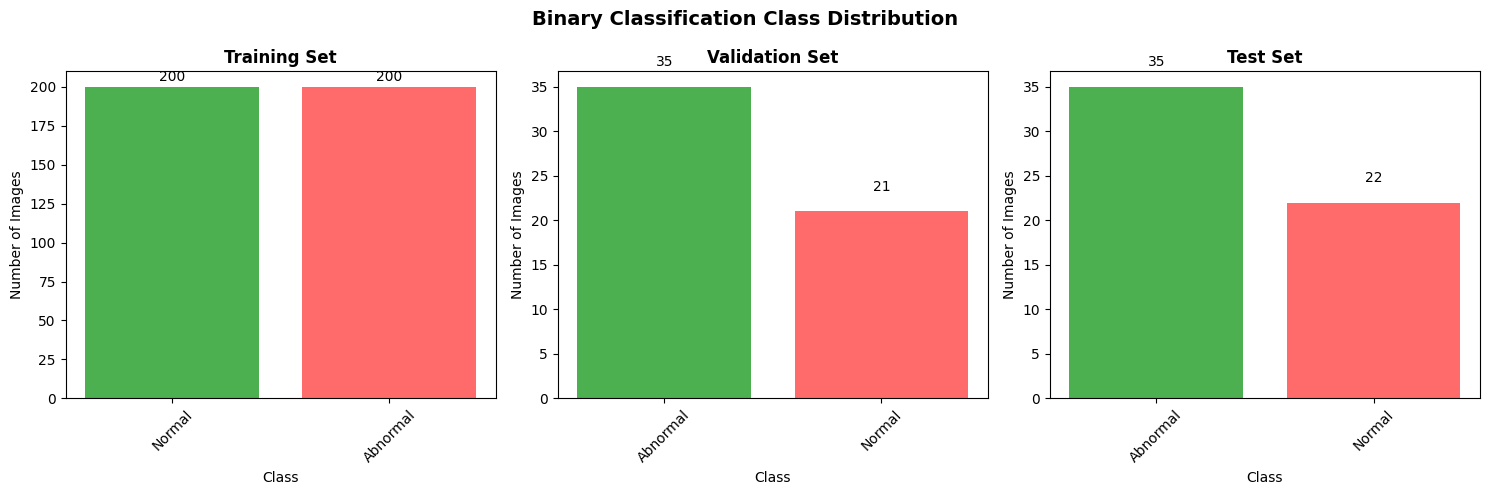


  Steps per epoch:
    Train: 25
    Validation: 4
    Test: 4

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000

[4] BUILDING MOBILENETV2 MODEL

  Base Model Layers: 154
  Output Classes: 2

  Total Parameters: 2,625,730
  Trainable Parameters: 364,418

[5] TRAINING MOBILENETV2

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7216 - loss: 0.5789
Epoch 1: val_accuracy improved from None to 0.62500, saving model to Binary Classification_phase1.keras

Epoch 1: finished saving model to Binary Classification_phase1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7825 - loss: 0.4717 - val_accuracy: 0.6250 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8529 - loss: 0.4925
Epoch 2: val_accuracy improved from 0.62500 to 0.73214, saving model to Binary Classification_phase1.keras

Epoch 2: finished

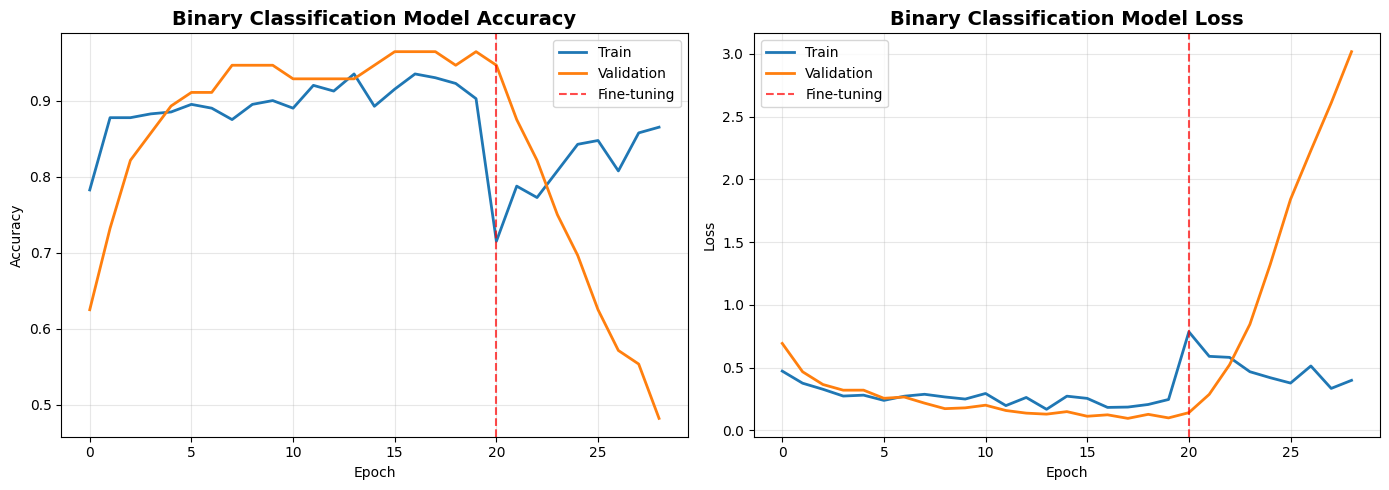

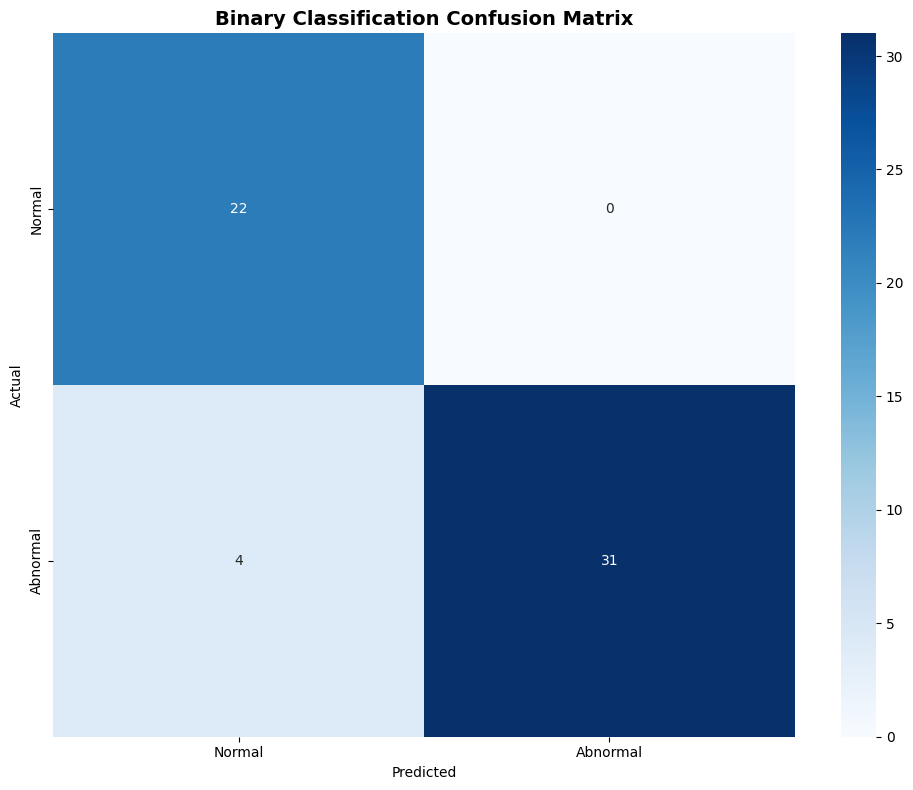

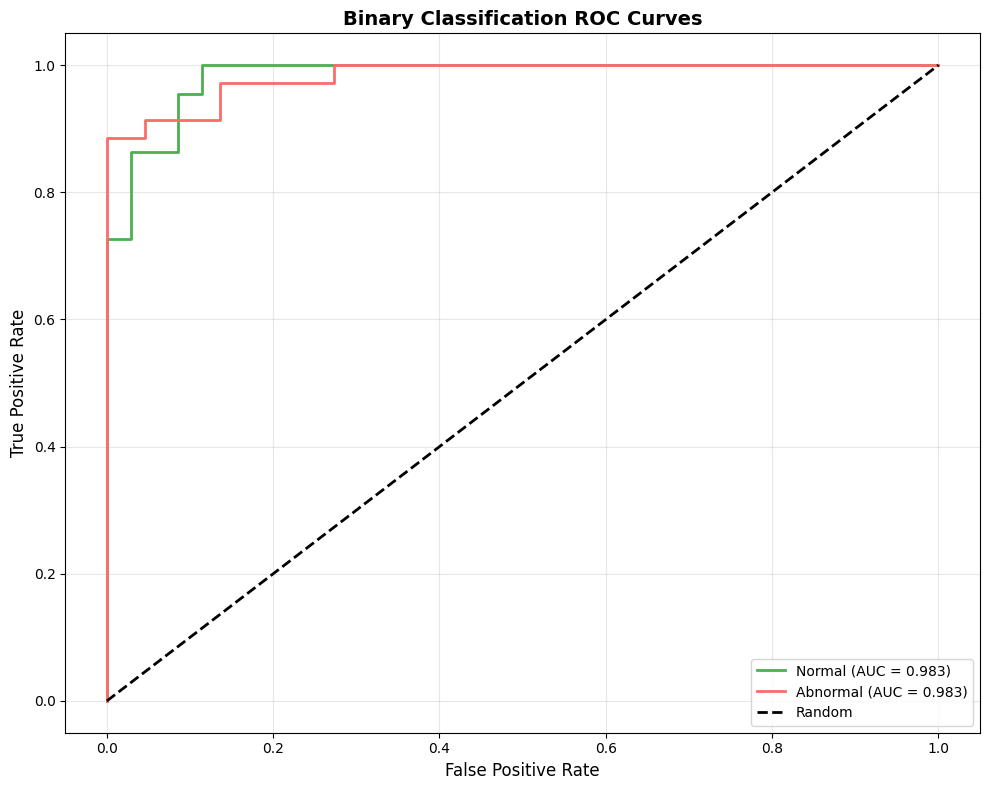


Binary Classification - FINAL SUMMARY

  Test Accuracy: 92.98%
  Test Loss: 0.2457

  Per-Class Performance:
  ------------------------------------------------------------
  Class                Accuracy     AUC     
  ------------------------------------------------------------
  Normal               100.00%      0.983
  Abnormal              88.57%      0.983

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      1.00      0.92        22
    Abnormal       1.00      0.89      0.94        35

    accuracy                           0.93        57
   macro avg       0.92      0.94      0.93        57
weighted avg       0.94      0.93      0.93        57


  Confusion Matrix:
          Normal  Abnormal
Normal        22         0
Abnormal       4        31

  Overfitting Analysis:
    Level: HIGH
    Accuracy Gap: 0.3829
    Train Accuracy: 86.50%
    Validation Accuracy: 48.21%
    Recommendation: Increase regularization

[7] EXPORT

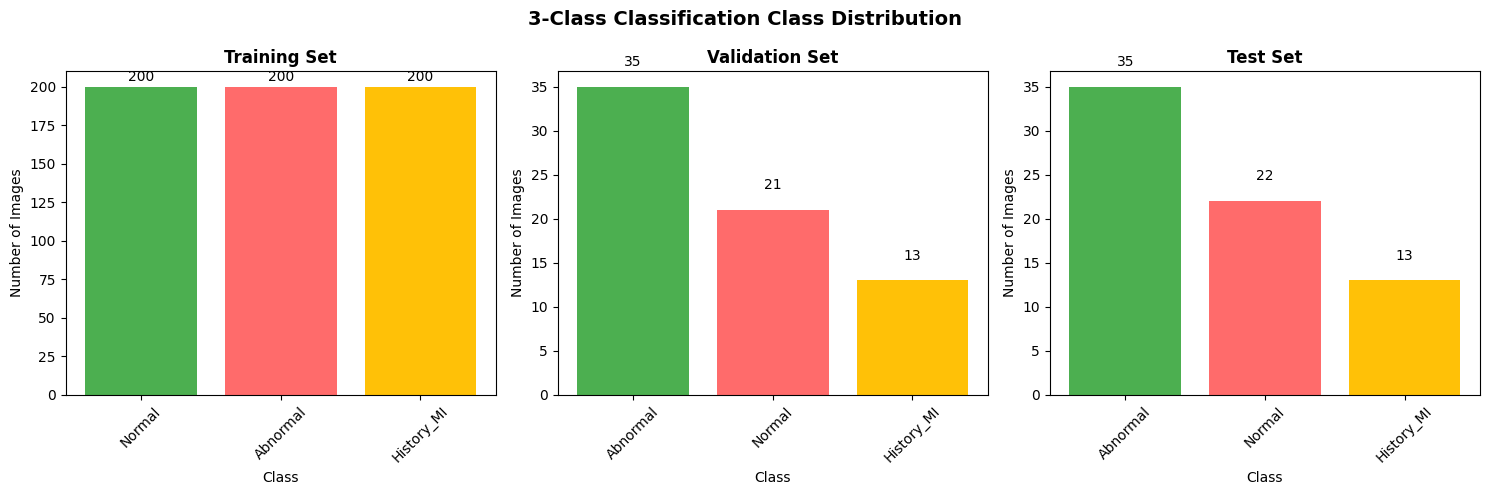


  Steps per epoch:
    Train: 38
    Validation: 5
    Test: 5

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000

[4] BUILDING MOBILENETV2 MODEL

  Base Model Layers: 154
  Output Classes: 3

  Total Parameters: 2,625,859
  Trainable Parameters: 364,547

[5] TRAINING MOBILENETV2

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4347 - loss: 1.5127
Epoch 1: val_accuracy improved from None to 0.34783, saving model to 3-Class Classification_phase1.keras

Epoch 1: finished saving model to 3-Class Classification_phase1.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.5000 - loss: 1.3089 - val_accuracy: 0.3478 - val_loss: 1.0353 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5889 - loss: 1.0125
Epoch 2: val_accuracy improved from 0.34783 to 0.57971, saving model to 3-Clas

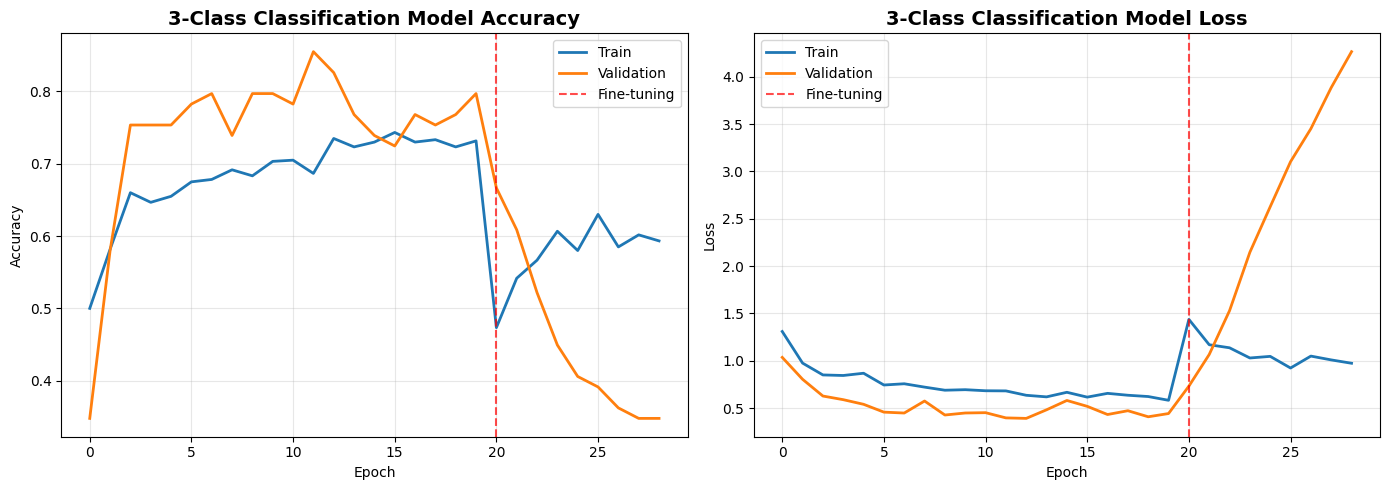

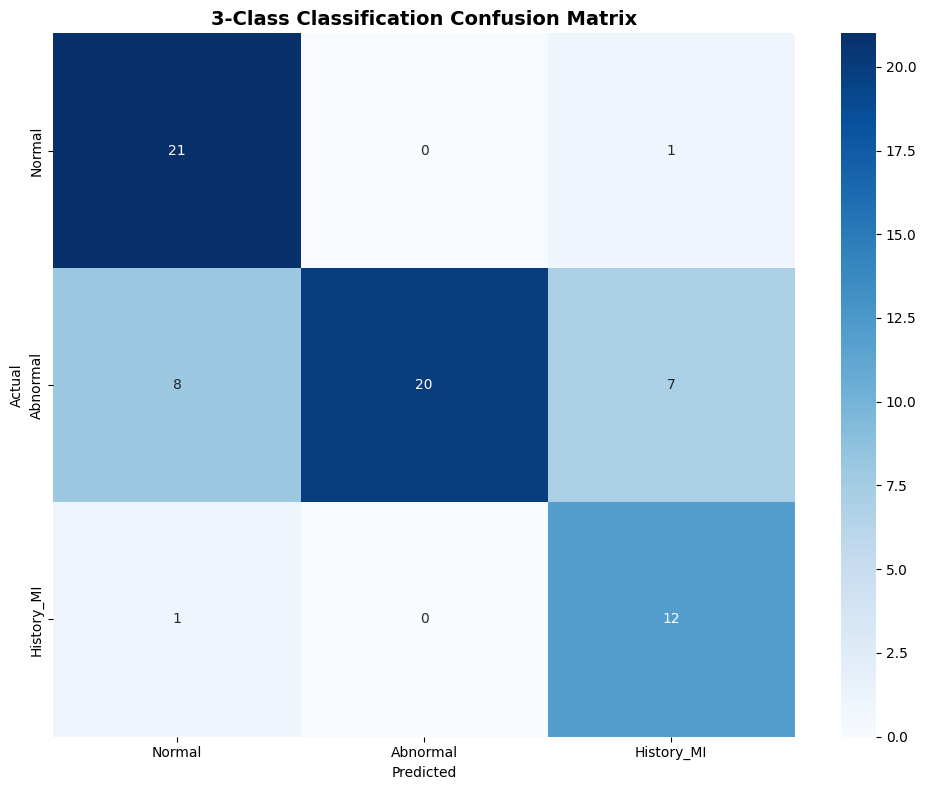

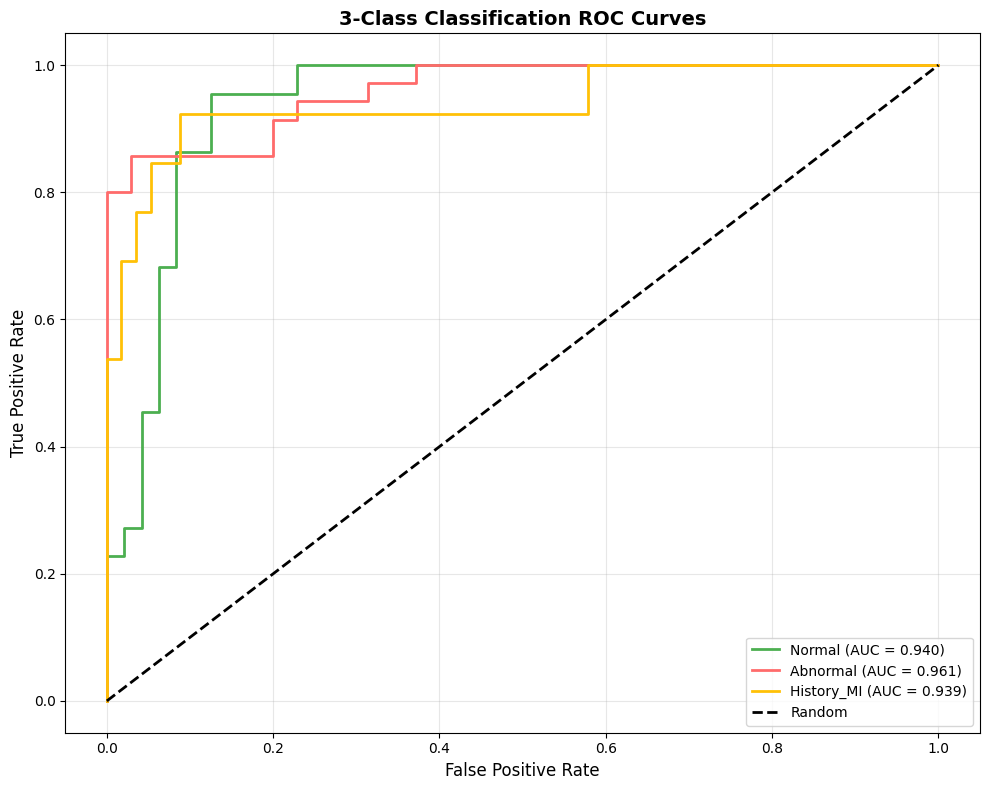


3-Class Classification - FINAL SUMMARY

  Test Accuracy: 75.71%
  Test Loss: 0.7555

  Per-Class Performance:
  ------------------------------------------------------------
  Class                Accuracy     AUC     
  ------------------------------------------------------------
  Normal                95.45%      0.940
  Abnormal              57.14%      0.961
  History_MI            92.31%      0.939

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.95      0.81        22
    Abnormal       1.00      0.57      0.73        35
  History_MI       0.60      0.92      0.73        13

    accuracy                           0.76        70
   macro avg       0.77      0.82      0.75        70
weighted avg       0.83      0.76      0.75        70


  Confusion Matrix:
            Normal  Abnormal  History_MI
Normal          21         0           1
Abnormal         8        20           7
History_MI       1         0          12


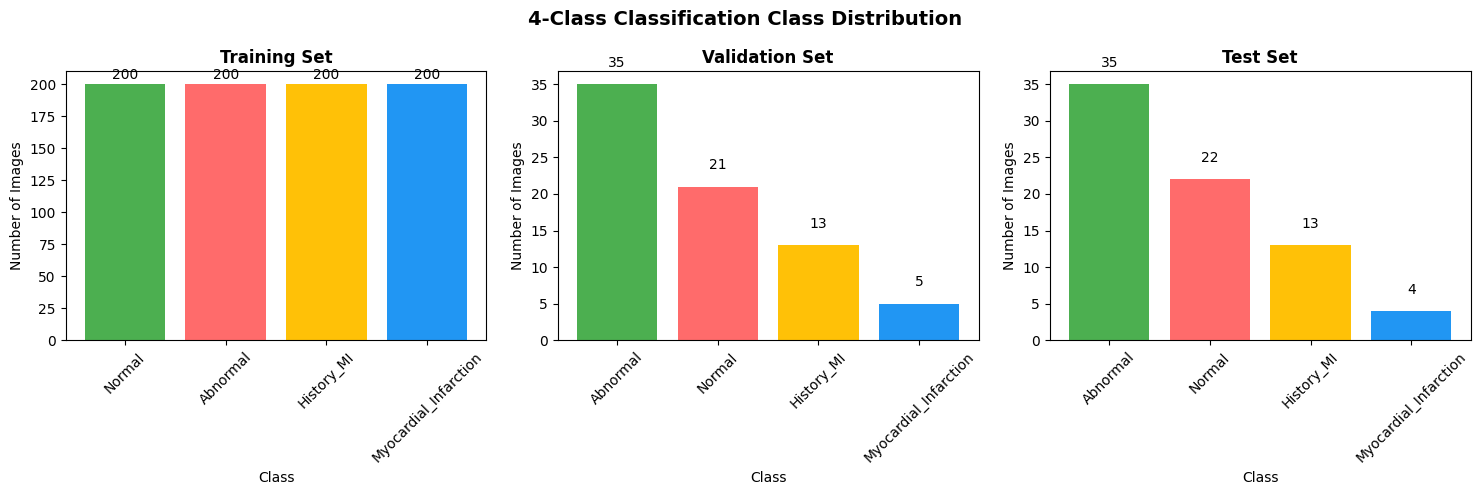


  Steps per epoch:
    Train: 50
    Validation: 5
    Test: 5

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000
    Myocardial_Infarction: 1.000

[4] BUILDING MOBILENETV2 MODEL

  Base Model Layers: 154
  Output Classes: 4

  Total Parameters: 2,625,988
  Trainable Parameters: 364,676

[5] TRAINING MOBILENETV2

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000
    Myocardial_Infarction: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3583 - loss: 1.8341
Epoch 1: val_accuracy improved from None to 0.39189, saving model to 4-Class Classification_phase1.keras

Epoch 1: finished saving model to 4-Class Classification_phase1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.4363 - loss: 1.5592 - val_accuracy: 0.3919 - val_loss: 1.4565 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5481 - loss: 1.2087
Epoch 2: val

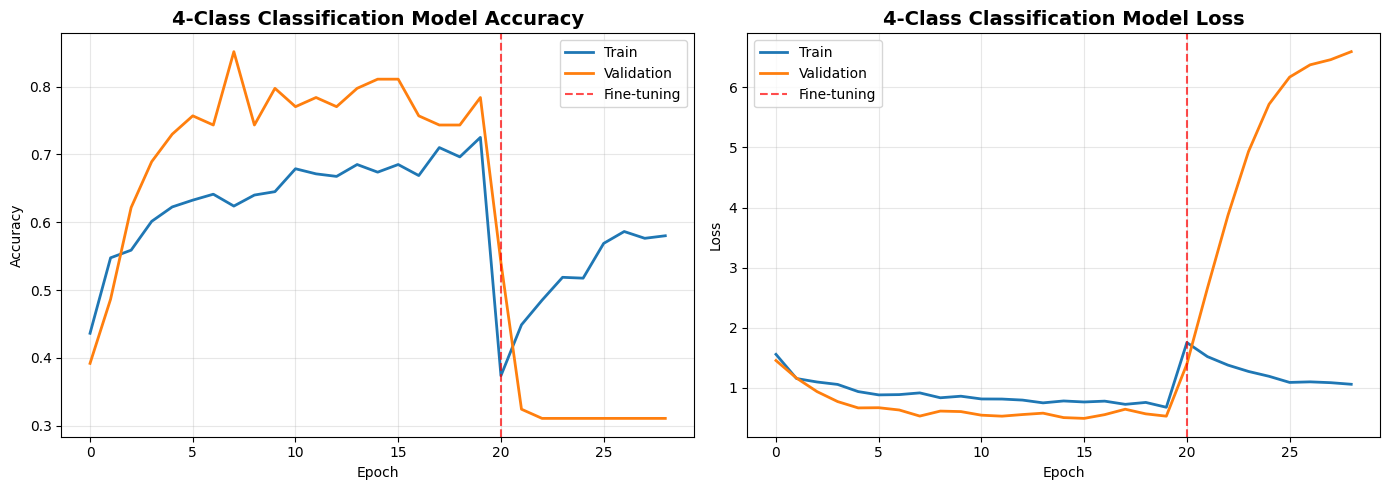

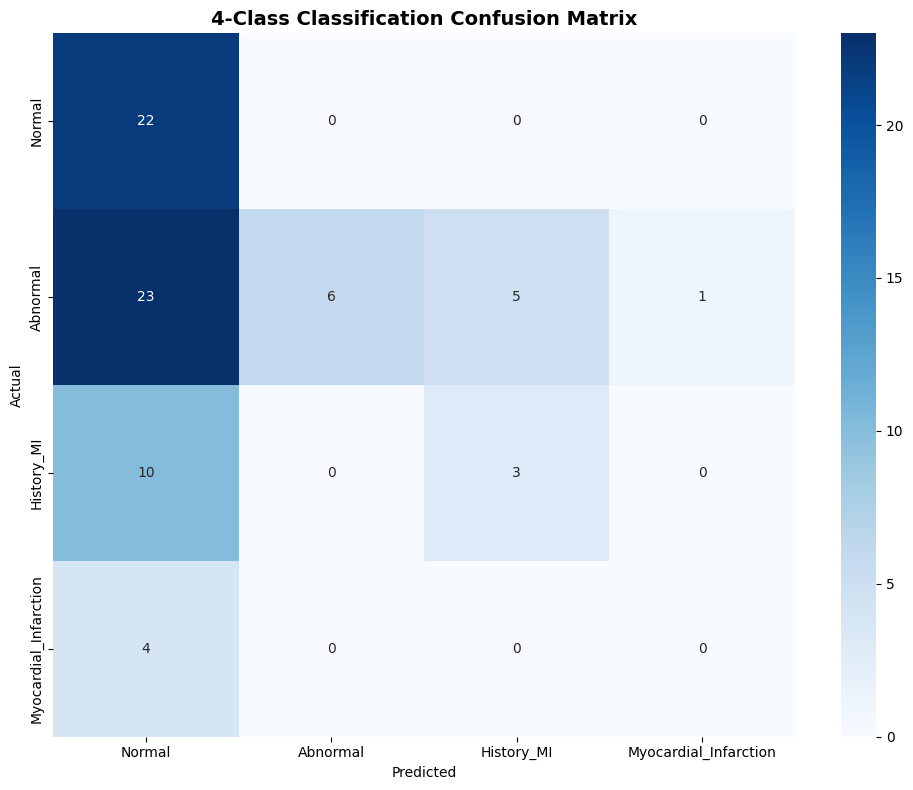

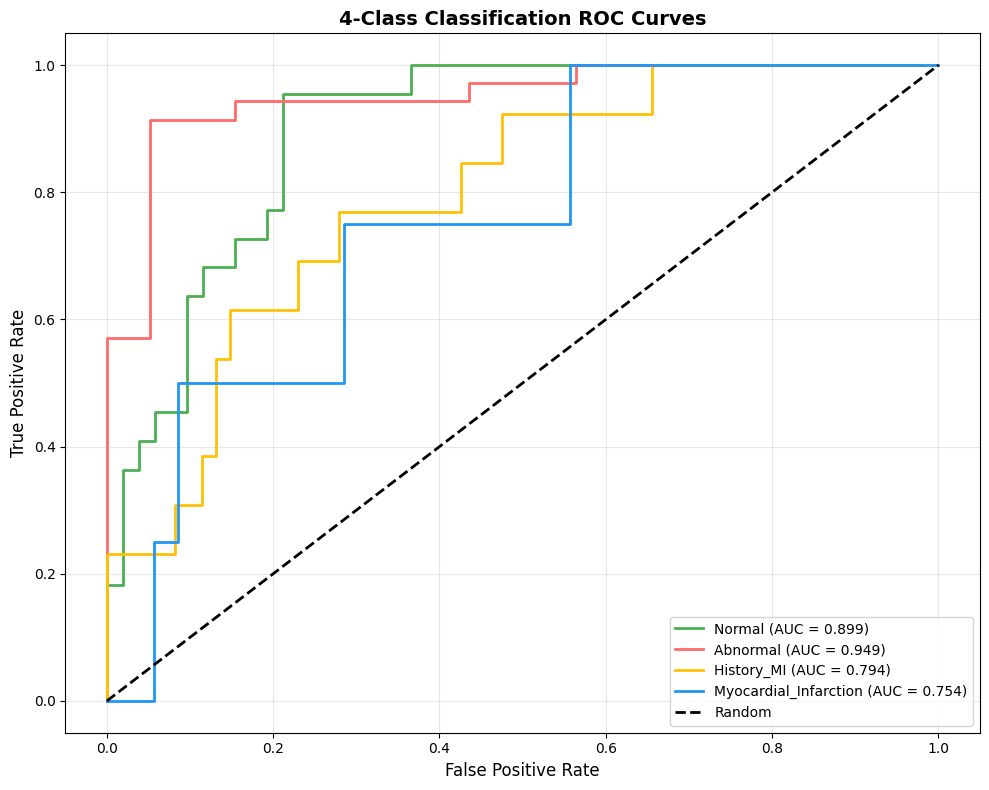


4-Class Classification - FINAL SUMMARY

  Test Accuracy: 41.89%
  Test Loss: 1.7258

  Per-Class Performance:
  ------------------------------------------------------------
  Class                Accuracy     AUC     
  ------------------------------------------------------------
  Normal               100.00%      0.899
  Abnormal              17.14%      0.949
  History_MI            23.08%      0.794
  Myocardial_Infarction   0.00%      0.754

  Classification Report:
                       precision    recall  f1-score   support

               Normal       0.37      1.00      0.54        22
             Abnormal       1.00      0.17      0.29        35
           History_MI       0.38      0.23      0.29        13
Myocardial_Infarction       0.00      0.00      0.00         4

             accuracy                           0.42        74
            macro avg       0.44      0.35      0.28        74
         weighted avg       0.65      0.42      0.35        74


  Confusion Mat

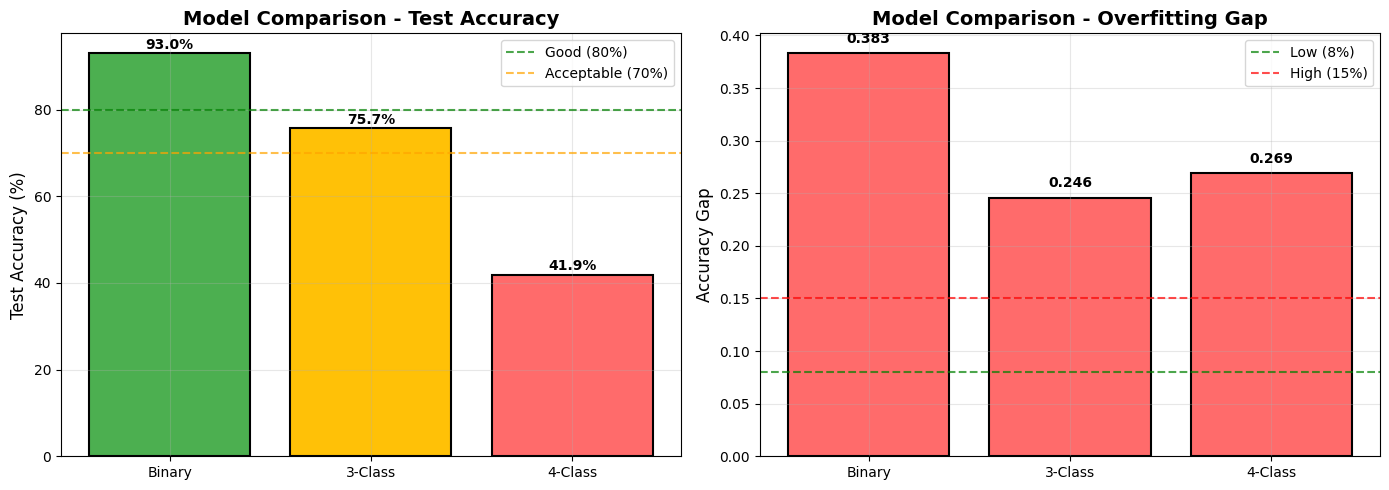


ALL EXPERIMENTS COMPLETED SUCCESSFULLY!
Models saved:
  - mobilenet_binary_model.keras / .onnx
  - mobilenet_3class_model.keras / .onnx
  - mobilenet_4class_model.keras / .onnx


In [ ]:
# ============================================================
#  14: 1 - Binary Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 1: BINARY CLASSIFICATION")
print("Normal vs Abnormal")
print("="*80)

experiment1 = ExperimentRunner(
    class_names=['Normal', 'Abnormal'],
    experiment_name="Binary Classification",
    output_prefix="mobilenet_binary"
)
results1, model1, history1 = experiment1.run()

# ============================================================
# الخلية 15: 2 - 3-Class Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 2: 3-CLASS CLASSIFICATION")
print("Normal vs Abnormal vs History_MI")
print("="*80)

experiment2 = ExperimentRunner(
    class_names=['Normal', 'Abnormal', 'History_MI'],
    experiment_name="3-Class Classification",
    output_prefix="mobilenet_3class"
)
results2, model2, history2 = experiment2.run()

# ============================================================
#  3 - 4-Class Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 3: 4-CLASS CLASSIFICATION")
print("Normal vs Abnormal vs History_MI vs Myocardial_Infarction")
print("="*80)

experiment3 = ExperimentRunner(
    class_names=['Normal', 'Abnormal', 'History_MI', 'Myocardial_Infarction'],
    experiment_name="4-Class Classification",
    output_prefix="mobilenet_4class"
)
results3, model3, history3 = experiment3.run()
# ============================================================
# الخلية 17: جدول المقارنة النهائي
# ============================================================

print("\n" + "="*80)
print("COMPARISON SUMMARY - ALL EXPERIMENTS")
print("="*80)

comparison_data = {
    'Experiment': ['Binary', '3-Class', '4-Class'],
    'Classes': ['2', '3', '4'],
    'Test Accuracy (%)': [
        results1['accuracy'] * 100,
        results2['accuracy'] * 100,
        results3['accuracy'] * 100
    ],
    'Test Loss': [
        results1['loss'],
        results2['loss'],
        results3['loss']
    ],
    'Overfitting Level': [
        OverfittingAnalyzer.analyze(history1)['level'],
        OverfittingAnalyzer.analyze(history2)['level'],
        OverfittingAnalyzer.analyze(history3)['level']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n  Comparison Table:")
print(comparison_df.to_string(index=False))

# عرض الرسوم البيانية المقارنة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# مقارنة الدقة
experiments = ['Binary', '3-Class', '4-Class']
accuracies = [results1['accuracy']*100, results2['accuracy']*100, results3['accuracy']*100]
colors = ['#4CAF50' if acc > 80 else '#FFC107' if acc > 70 else '#FF6B6B' for acc in accuracies]

axes[0].bar(experiments, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=80, color='green', linestyle='--', label='Good (80%)', alpha=0.7)
axes[0].axhline(y=70, color='orange', linestyle='--', label='Acceptable (70%)', alpha=0.7)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# مقارنة فرط التخصص
gaps = [
    OverfittingAnalyzer.analyze(history1)['final_gap'],
    OverfittingAnalyzer.analyze(history2)['final_gap'],
    OverfittingAnalyzer.analyze(history3)['final_gap']
]
colors_gap = ['#4CAF50' if gap < 0.08 else '#FFC107' if gap < 0.15 else '#FF6B6B' for gap in gaps]

axes[1].bar(experiments, gaps, color=colors_gap, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=0.08, color='green', linestyle='--', label='Low (8%)', alpha=0.7)
axes[1].axhline(y=0.15, color='red', linestyle='--', label='High (15%)', alpha=0.7)
axes[1].set_ylabel('Accuracy Gap', fontsize=12)
axes[1].set_title('Model Comparison - Overfitting Gap', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(gaps):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("Models saved:")
print("  - mobilenet_binary_model.keras / .onnx")
print("  - mobilenet_3class_model.keras / .onnx")
print("  - mobilenet_4class_model.keras / .onnx")
print("="*80)

